In [1]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time

In [2]:
patch_size = 50
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
max_skew = 0

margin = 2500
learning_rate = 0.00001
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
batch_size = 256
epochs = 100000
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [3]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [4]:
def get_random_homography_matrix():
    rotation = np.random.uniform(0,max_rotation)
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [5]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_path, batch_size = 128):
        self.img = cv2.imread(image_path)
        self.img = cv2.resize(self.img, (image_size, image_size))
        self.img = cv2.cvtColor(self.img, cv2.COLOR_RGB2GRAY)
        self.img = self.img/255
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        for _ in range(self.batchsize):
            x = np.random.randint(0,image_size - patch_size)
            y = np.random.randint(0,image_size - patch_size)
            current_patch = self.img[x:x+patch_size, y:y+patch_size]
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            X = np.random.randint(0,image_size - patch_size)
            Y = np.random.randint(0,image_size - patch_size)
            
            while(x==X & y==Y):
                X = np.random.randint(0,image_size - patch_size)
                Y = np.random.randint(0,image_size - patch_size)
                
            current_patch = self.img[X:X+patch_size, Y:Y+patch_size]
            transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)
        
        return np.array(original_images), np.array(matches), np.array(non_matches)

In [6]:
# class ChannelNormalization(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ChannelNormalization, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.l2_normalize(inputs, axis=-1)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ChannelNormalization, self).build(input_shape)
        
#     def get_config(self):
#         return super(ChannelNormalization, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [7]:
# class ClippingLayer(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ClippingLayer, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.clip(inputs, min_value=0.0, max_value=256.0)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ClippingLayer, self).build(input_shape)
        
#     def get_config(self):
#         return super(ClippingLayer, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [8]:
# def get_model(input_shape, descriptor_dimension):
#     inp = tf.keras.layers.Input(input_shape)
#     out = tf.keras.layers.Conv2D(descriptor_dimension, kernel_size)(inp)
#     # out = ClippingLayer()(out)
#     out = ChannelNormalization()(out)
    
#     model = tf.keras.models.Model(inputs = inp, outputs = out)
#     return model

In [9]:
# def custom_loss(original_desc, matches, non_matches):
#     original_desc = tf.squeeze(original_desc)
#     matches = tf.squeeze(matches)
#     non_matches = tf.squeeze(non_matches)
    
#     return tf.reduce_mean((1 - tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(matches, tf.transpose(non_matches))))
    

In [10]:
# model = get_model((patch_size, patch_size, 1), descriptor_dimension)
# model.summary()

In [11]:
# data_gen = CustomDataGenerator("test/img/cinema1.jpeg", batch_size)

# for epoch in range(epochs):
#     epoch_loss = 0
#     print(f"Epoch {epoch} starting...")
#     for batch in range(data_gen.__len__()):
#         all_patches, matches, non_matches = data_gen.__getitem__(batch)
#         with tf.GradientTape() as tape:
#             all_predictions = model(all_patches)
#             matches_predictions = model(matches)
#             non_matches_predictions = model(non_matches)
#             loss = custom_loss(all_predictions, matches_predictions, non_matches_predictions)
#             # print(loss)
#             epoch_loss += loss
#             gradients = tape.gradient(loss, model.trainable_variables)
#             optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
#         # if batch%5==0:
#         #     print(loss.numpy())
#     # val_generator.on_epoch_end()
    
#     try:
#         model.save(model_path)
#         model.save(backup_model_path)
#     except Exception as e:
#         print("========= Note ================")
#         print("cant save last model")
#         print(e)
    
#     print(epoch_loss.numpy()/data_gen.__len__())
#     epoch_loss = 0

In [12]:
val_data_gen = CustomDataGenerator("test/img/cinema1.jpeg", 1)

In [13]:
# og, match, no_match = val_data_gen.__getitem__(0)
# fig, ax = plt.subplots(ncols=3, figsize = (11,5))
# # sns.heatmap(og[0,:,:,0], ax = ax[0], cbar = False, vmin=0, vmax=1)
# sns.heatmap(match[0,:,:,0], ax = ax[1], cbar = False, vmin=0, vmax=1)
# sns.heatmap(no_match[0,:,:,0], ax = ax[2], cbar = False, vmin=0, vmax=1)

In [14]:
filter = np.random.normal(0.5, 1/12, (patch_size, patch_size))
filter = np.clip(filter, 0, 1)
filter = tf.Variable(tf.convert_to_tensor(filter))

In [15]:
# sns.heatmap(filter)

In [16]:
# bce = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
# # sns.heatmap(bce)


In [17]:
def custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img):
    desc1_og_img_sum = tf.reduce_sum(desc1_og_img)
    desc1_trans_img_sum = tf.reduce_sum(desc1_trans_img)
    desc1_rand_img_sum = tf.reduce_sum(desc1_rand_img)
    loss = tf.maximum(0, abs(desc1_og_img_sum - desc1_trans_img_sum) - abs(desc1_rand_img_sum - desc1_og_img_sum) + margin)
    return loss

In [18]:
for i in range(epochs):
    og, match, no_match = val_data_gen.__getitem__(0)
    with tf.GradientTape() as tape:
        desc1_og_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(og[0,:,:,0], filter))
        desc1_trans_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(match[0,:,:,0], filter))
        desc1_rand_img = 2*tf.keras.activations.sigmoid(-tf.keras.backend.binary_crossentropy(no_match[0,:,:,0], filter))
        
        loss = custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img)
        gradients = tape.gradient(loss, [filter])
        optimizer.apply_gradients(zip(gradients, [filter]))
        
    if i%50 == 0:
        print(loss.numpy())
        

2499.669897414038
2501.6695790350336
2502.0428798978273
2499.6950552966146
2500.5181346580384
2496.749405338598
2500.4102037916564
2499.5336725365596
2498.716090195406
2500.7348156265334
2501.0093017872287
2497.700362614055
2500.0328452686217
2500.8423729721235
2498.897861678439
2499.7086017369297
2500.030780438917
2499.8676836374125
2500.9819335421894
2499.8284398104674
2499.6078750289644
2499.9363823980802
2499.3357265556224
2501.7518929840417
2498.6601021784572
2500.6650078145294
2501.0287266156934
2501.2767130833245
2501.453224555543
2496.7226506334628
2499.2657470719423
2497.7723019867244
2500.126275354127
2499.2642287105364
2498.05479853037
2498.3151301709795
2499.8729421285016
2499.306621171094
2499.9007749749353
2500.459191737924
2499.7638059126975
2498.342892598466
2499.238773053501
2499.4284347033745
2498.597405201665
2499.3919068815903
2499.8153243890347
2500.605392057685
2500.3434499830983
2499.5531184930487
2501.436822805994
2499.5437389273975
2497.682179367593
2497.123909

KeyboardInterrupt: 

<Axes: >

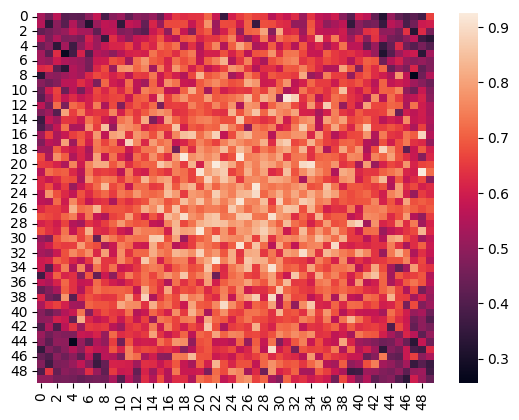

In [19]:
sns.heatmap(filter)